In [ ]:
# 초기 1회 실행
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Lesson 5-3 Project(sol)

In [ ]:
## 필요 패키지 설치 및 import
import importlib.util
import subprocess
import sys
def install_and_import(packages):
    for pkg in packages:
        package = pkg
        try:
            importlib.util.find_spec(package)
            print(f"{package} is already installed.")
        except ImportError:
            # 모듈이 설치되어 있지 않은 경우 설치시도
            print(f"{package} is not installed. Installing...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])
            subprocess.check_call(["conda", "install", package, "-y"])

            # 설치 후 다시 임포트를 시도
            importlib.import_module(package)
            print(f"{package} has been successfully installed.")

        # finally:
        #     globals()[package] = importlib.import_module(package)
        except Exception as e:
            # 설치 중 예외가 발생한 경우, 에러 메시지를 출력
            print(f"An error occurred while installing {package}: {str(e)}")

# 예시 사용법
# install_and_import([''])


In [ ]:
ppath = '/content/drive/MyDrive/5. STUDY_ETC/Metacode/lesson5'

In [ ]:
## 필요 모듈 임포트
import os, sys, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score as ARI

#1. Breat Cancer Data

- 데이터: Breast_cancer Data
각종 정보들을 가지고 암 여부 진단  
- (종속변수 : diagnosis 변수, (M = malignant, B = benign))
- 참고: https://www.Kaggle.com/uciml/breast-cancer-Wisconsin-data/downloads/breast-cancer-Wisconsin-data.zip/2


##1. data 폴더 내 데이터 입력

In [ ]:
## 1. 데이터 불러오기
data = pd.read_csv(ppath + '/1. data/breast_cancer.csv')
data.head(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


## diagnosis 변수는 범주형 변수로 변환

In [ ]:
## diagnosis 변수는 범주형 변수로 변환
le = LabelEncoder()
data['diagnosis'] = le.fit_transform(data['diagnosis'])  # M = 1, B = 0

## 범주형 변수 id, diagnosis 제거 후 데이터 표준화

In [ ]:
## 범주형 변수 id, diagnosis 제거
data_id_removed = data.drop(columns = ['id', 'diagnosis'])

## 후 데이터 표준화
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_id_removed)

## 군집화 수행

## Kmeans

In [ ]:
## KMeans 군집화 수행 (클러스터 수는 2로 설정)
kmeans = KMeans(n_clusters = 2,
                                    #   random_state = 1
                )
kmeans

KMeans(n_clusters=2)

In [ ]:
data['kmeans_class'] = kmeans.fit_predict(data_scaled)
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,kmeans_class
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


## 계층적 군집화

In [ ]:
## 계층적 군집화 수행
linkage_matrix = linkage(data_scaled, # 표준화된 데이터
                                                    method = 'ward', # 연결법, 'complete', 'average', 'weighted', 'centroid'
                                                    metric = 'euclidean')

## linkage_matrix 계층적 군집화 결과
linkage_matrix[:10]

array([[ 79.        , 362.        ,   1.00611495,   2.        ],
       [457.        , 458.        ,   1.027614  ,   2.        ],
       [271.        , 390.        ,   1.09709635,   2.        ],
       [  6.        , 317.        ,   1.10097598,   2.        ],
       [ 90.        , 545.        ,   1.12085268,   2.        ],
       [298.        , 477.        ,   1.1477104 ,   2.        ],
       [ 74.        , 137.        ,   1.14871173,   2.        ],
       [107.        , 497.        ,   1.21059161,   2.        ],
       [425.        , 522.        ,   1.21624611,   2.        ],
       [158.        , 294.        ,   1.21800772,   2.        ]])

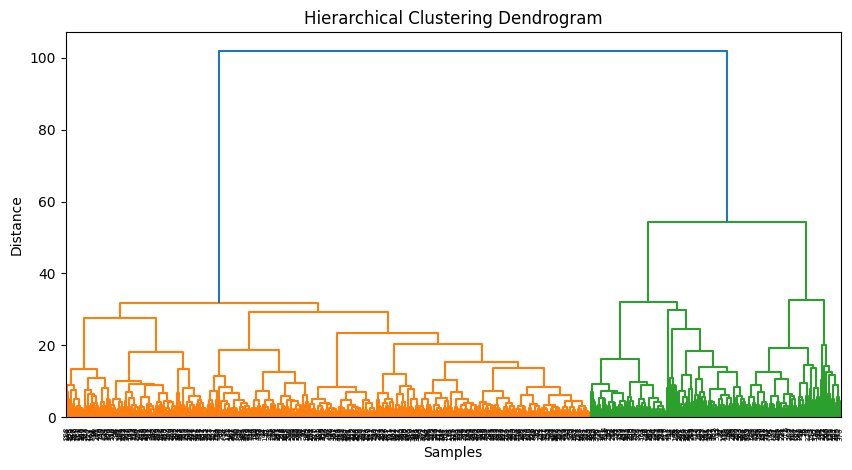

In [ ]:
## 참고..덴드로그램 그리기
plt.figure(figsize = (10, 5)) # 가로, 세로 인치..

dendrogram(linkage_matrix,
                           orientation = 'top',  # 'right', 등등
                           # color_threshold = 1.5 # 이 값 기준으로 자동 색 할당
                             )
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show() ## 자동 색 할당..

In [ ]:
## 클러스터 나누기
## 2. 개수로 지정하기
clusters = fcluster(Z = linkage_matrix,
                                      t = 2,    # 생성할 클러스터의 최대 개수
                                      criterion = 'maxclust'
)


## 클러스터 개수 확인
np.unique(clusters, return_counts=True)

(array([1, 2], dtype=int32), array([385, 184]))

In [ ]:
## 군집결과를 class라는 변수에 저장
data['hc_class'] = clusters
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,kmeans_class,hc_class
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1,2
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1,2
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1,2
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1,2
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1,2


## 두개 군집화 모형의 군집결과 평가

### T-SNE 적용하여 시각화 (class 변수, diagnosis 변수 각각 시각화)


In [ ]:
## T-SNE 적용하여 시각화
tsne = TSNE(n_components = 2, random_state = 123)

tsne_result = tsne.fit_transform(data_scaled)

data['tsne-1'] = tsne_result[:, 0]
data['tsne-2'] = tsne_result[:, 1]

In [ ]:
## tsne df 생성
tsne_df = pd.DataFrame(tsne_result,
                                                    columns = ['tsne-1', 'tsne-2'])
tsne_df['diagnosis'] = data['diagnosis']
tsne_df['kmeans_class'] = data['kmeans_class']
tsne_df['hc_class'] = data['hc_class']
tsne_df.head()

,tsne-1,tsne-2,diagnosis,kmeans_class,hc_class
0,38.578911,2.494724,1,1,2
1,24.303450,6.943472,1,1,2
2,31.938700,3.564493,1,1,2
3,20.674002,-13.834522,1,1,2
4,28.447147,-3.087035,1,1,2


In [ ]:
## 각 class의 level 확인
tsne_df['diagnosis'].value_counts(), tsne_df['kmeans_class'].value_counts(), tsne_df['hc_class'].value_counts()

(diagnosis
 0    357
 1    212
 Name: count, dtype: int64,
 kmeans_class
 0    381
 1    188
 Name: count, dtype: int64,
 hc_class
 1    385
 2    184
 Name: count, dtype: int64)

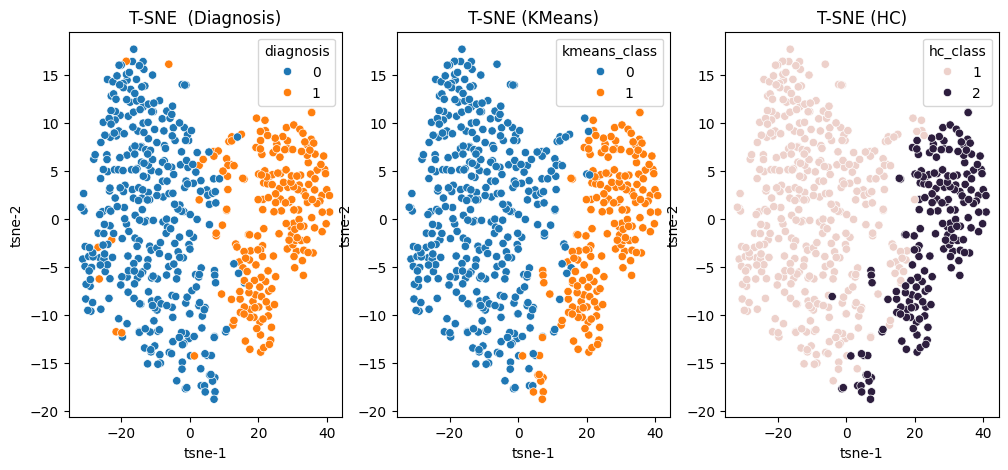

In [ ]:
## KMeans
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(
    x = "tsne-1", y = "tsne-2",
    hue = "diagnosis",
    data = tsne_df,
    legend = "full"
)
plt.title("T-SNE  (Diagnosis)") ## tsne_df['diagnosis']의 class가 0, 1

# T-SNE 시각화 (Diagnosis 결과)
plt.subplot(1, 3, 2)
sns.scatterplot(
    x = "tsne-1", y = "tsne-2",
    hue = "kmeans_class",
    data = tsne_df,
    legend = "full"
)
plt.title("T-SNE (KMeans)") ## tsne_df['kmeans_class']의 class가 0, 1

plt.subplot(1, 3, 3)
sns.scatterplot(
    x = "tsne-1", y = "tsne-2",
    hue = "hc_class",
    data = tsne_df,
    legend = "full"
)
plt.title("T-SNE (HC)") ## tsne_df['hc_class']의 class가 1,2

plt.show()

### 원 데이터의 diagnosis 변수와 비교(ARI 활용)


In [ ]:
kmeans_ari = ARI(data['diagnosis'], data['kmeans_class'])
kmeans_ari

0.676504895633523

In [ ]:
hc_ari = ARI(data['diagnosis'], data['hc_class'])
hc_ari

0.5750409366326297

# Happiness dataset

- 데이터 : Happiness dataset
- 국가별 행복도 조사 데이터
- 참고: https://www.kaggle.com/unsdsn/world-happiness#2017.csv

In [ ]:
# 필요한 라이브러리 불러오기
import os, sys, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder, StandardScaler

## 데이터 읽기

In [ ]:
happy = pd.read_csv(ppath + '/1. data/2017_happiness2.csv')
happy.head()

,Country,Whisker_high,Whisker_low,Economy_GDP_per_Capita,Family,Health_Life_Expectancy,Freedom,Generosity,Trust_Government_Corruption,Dystopia_Residual,Happiness,Happiness_Rank
0,Yemen,3.692750,3.493250,0.591683,0.935382,0.310081,0.249464,0.104125,0.056767,1.345601,low,146
1,Ireland,7.043352,6.910649,1.535707,1.558231,0.809783,0.573110,0.427858,0.298388,1.773869,high,15
2,Belarus,5.646114,5.491885,1.156558,1.444945,0.637714,0.295400,0.155138,0.156314,1.723233,medium,67
3,United Kingdom,6.783792,6.644209,1.441634,1.496460,0.805336,0.508190,0.492774,0.265428,1.704144,high,19
4,South Korea,5.922559,5.753441,1.401678,1.128274,0.900214,0.257922,0.206674,0.063283,1.880378,medium,55


## Country 변수를 범주형 변수로 변환

In [ ]:
## Country 변수를 범주형 변수로 변환
le = LabelEncoder()
happy['Country'] = le.fit_transform(happy['Country'])

## NA값 확인 후 제거

In [ ]:
happy.dropna(inplace=True)

## PCA

### 범주형 변수(Country, Happiness, Happiness_Rank) 제거

In [ ]:
## 범주형 변수(Country, Happiness, Happiness_Rank) 제거
happy_continuous = happy.drop(columns=['Country', 'Happiness', 'Happiness_Rank'])
happy_continuous


,Whisker_high,Whisker_low,Economy_GDP_per_Capita,Family,Health_Life_Expectancy,Freedom,Generosity,Trust_Government_Corruption,Dystopia_Residual
0,3.692750,3.493250,0.591683,0.935382,0.310081,0.249464,0.104125,0.056767,1.345601
1,7.043352,6.910649,1.535707,1.558231,0.809783,0.573110,0.427858,0.298388,1.773869
2,5.646114,5.491885,1.156558,1.444945,0.637714,0.295400,0.155138,0.156314,1.723233
3,6.783792,6.644209,1.441634,1.496460,0.805336,0.508190,0.492774,0.265428,1.704144
4,5.922559,5.753441,1.401678,1.128274,0.900214,0.257922,0.206674,0.063283,1.880378
...,...,...,...,...,...,...,...,...,...
150,5.319278,5.226721,1.081166,1.160837,0.741416,0.472788,0.028807,0.022794,1.764939
151,5.577381,5.408619,0.932537,1.507285,0.579251,0.473508,0.224151,0.091066,1.685333
152,5.885181,5.758819,1.130777,1.493149,0.437726,0.418272,0.249925,0.259270,1.832910
153,4.377164,4.206836,0.648457,1.272031,0.285349,0.096098,0.201870,0.136957,1.651637


### 표준화

In [ ]:
## 데이터 표준화
scaler = StandardScaler()
happy_continuous_scaled = scaler.fit_transform(happy_continuous)

### PCA 수행

In [ ]:
## PCA 수행
pca = PCA()
pca_result = pca.fit_transform(happy_continuous_scaled)

## PCA로 설명된 분산 비율
explained_variance = np.cumsum(pca.explained_variance_ratio_)
explained_variance

pd.DataFrame(explained_variance,
                              columns = ['explained_variance'],
                              index = happy_continuous.columns)

,explained_variance
Whisker_high,0.529407
Whisker_low,0.686422
Economy_GDP_per_Capita,0.810009
Family,0.885304
Health_Life_Expectancy,0.945476
Freedom,0.984598
Generosity,0.999810
Trust_Government_Corruption,1.000000
Dystopia_Residual,1.000000


## Biplot 그리고 해석하기

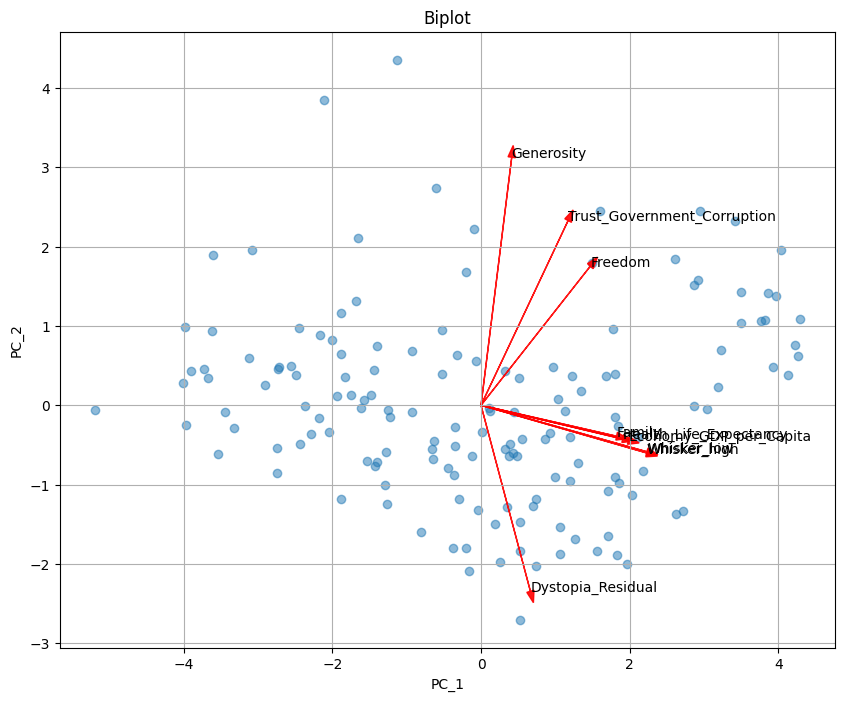

In [ ]:
## Biplot 그리기
def biplot(pca_data, pca_model, feature_names):
    plt.figure(figsize = (10, 8))
    plt.scatter(pca_data[:, 0], pca_data[:, 1], alpha=0.5)

    scaling_factor = 5
    for i, feature in enumerate(feature_names):
        plt.arrow(0, 0,
                            pca_model.components_[0, i]*scaling_factor,
                            pca_model.components_[1, i]*scaling_factor,
                            color = 'r',
                            alpha = 0.9,
                            head_width = 0.1)
        plt.text(pca_model.components_[0, i]*scaling_factor,
                        pca_model.components_[1, i]*scaling_factor,
                        feature, color = 'k')

    plt.xlabel('PC_1')
    plt.ylabel('PC_2')
    plt.title('Biplot')
    plt.grid()
    plt.show()

biplot(pca_result, pca, happy_continuous.columns)

## TSNE

In [ ]:
## PCA로 분산이 70% 되는 주성분만 사용
pca = PCA(n_components = 0.7)

happy_continuous_pca_70 = pca.fit_transform(happy_continuous_scaled)


In [ ]:
## T-SNE 적용 (PCA 전, 원본 데이터)
tsne = TSNE(n_components = 2,
                          # random_state= 123,
                          perplexity = 20,
                          max_iter = 500,
                          verbose = 1
                        )
tsne_result_original = tsne.fit_transform(happy_continuous_scaled)

[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 150 samples in 0.002s...
[t-SNE] Computed neighbors for 150 samples in 0.005s...
[t-SNE] Computed conditional probabilities for sample 150 / 150
[t-SNE] Mean sigma: 1.170441
[t-SNE] KL divergence after 250 iterations with early exaggeration: 55.549622
[t-SNE] KL divergence after 500 iterations: 0.494821


In [ ]:
## T-SNE 적용 (PCA 적용 후)
tsne_result_pca = tsne.fit_transform(happy_continuous_pca_70)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 150 samples in 0.001s...
[t-SNE] Computed neighbors for 150 samples in 0.013s...
[t-SNE] Computed conditional probabilities for sample 150 / 150
[t-SNE] Mean sigma: 1.123845
[t-SNE] KL divergence after 250 iterations with early exaggeration: 49.248520
[t-SNE] KL divergence after 500 iterations: 0.285929


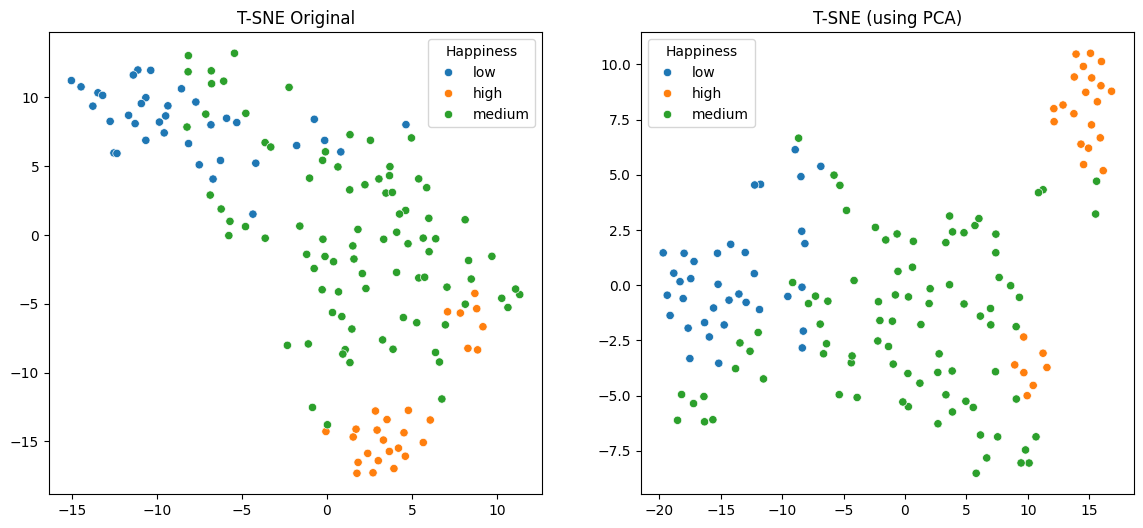

In [ ]:
## T-SNE 시각화 (PCA 적용 전후 비교)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(
                x = tsne_result_original[:, 0],
                y = tsne_result_original[:, 1],
                hue = happy['Happiness'],
)
plt.title('T-SNE Original')

plt.subplot(1, 2, 2)
sns.scatterplot(
                x = tsne_result_pca[:, 0],
                y = tsne_result_pca[:, 1],
                hue = happy['Happiness'],
)
plt.title('T-SNE (using PCA)')

plt.show()

In [ ]:
# EOS